In [1]:
import numpy as np
import torch, gc
import torch.nn as nn
from torch.optim import Adam
from Seq2Seq import Seq2Seq
from torch.utils.data import DataLoader, TensorDataset, random_split
# from torchviz import make_dot

import io
import imageio
from ipywidgets import widgets, HBox

import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Use GPU if available
print(torch.version.cuda)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

gc.collect()
torch.cuda.empty_cache()

None
cpu


In [2]:
# Load Data as Numpy Array
# sequences, seq_len, channels, height, width
data_CH4 = np.load("./data/input_convlstm/CH4_stacked_Poznan_Tokyo.npy").transpose(0,2,1,3,4)
# Shuffle Data
data_CH4 = np.float32(np.nan_to_num(data_CH4, nan=0.0))
print(data_CH4.mean())
np.random.shuffle(data_CH4)
print(data_CH4.shape)

targets_CH4 = torch.from_numpy(np.nan_to_num(data_CH4[:, :, 19, :, :], nan=0.0)).to(device)
data_CH4 = torch.from_numpy(np.nan_to_num(data_CH4[:, :, :19, :, :], nan=0.0)).to(device)
print(data_CH4.nbytes / 1024 / 1024)

dataset = TensorDataset(data_CH4, targets_CH4)#.to(device)

train_size = int(0.8*len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=True)



0.09878998
(1022, 1, 20, 64, 64)
303.40625


(8, 1, 19, 64, 64)
(1, 19, 64, 64)


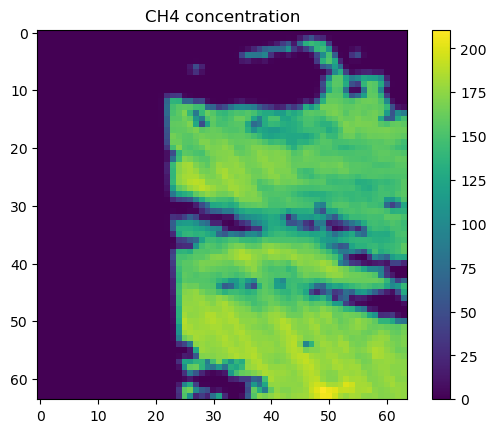

(8, 1, 19, 64, 64)
(1, 19, 64, 64)


C:\Users\Kajetan\miniconda3\envs\convlstm\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


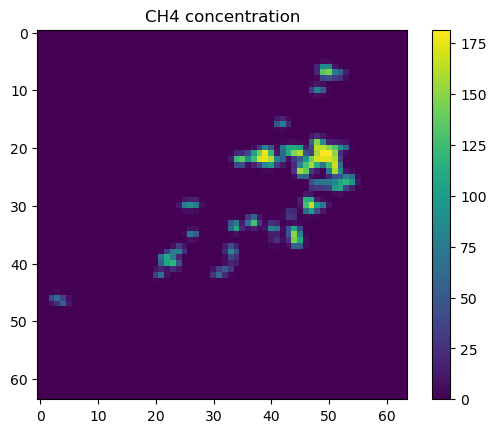

(8, 1, 19, 64, 64)
(1, 19, 64, 64)


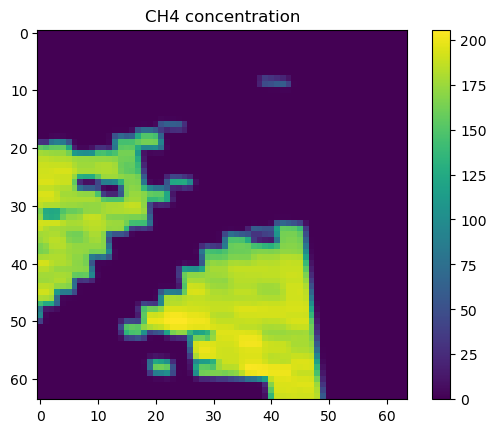

(8, 1, 19, 64, 64)
(1, 19, 64, 64)


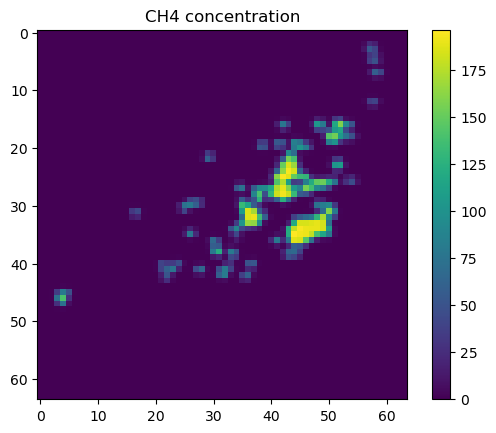

(8, 1, 19, 64, 64)
(1, 19, 64, 64)


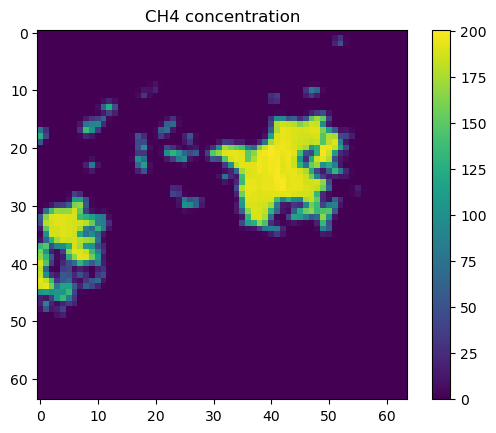

In [4]:
def create_animation(images, interval=100):
    fig, ax = plt.subplots()
    img_display = ax.imshow(images[0, 0])
    fig.colorbar(img_display)
    plt.title("CH4 concentration")
    
    def update(frame):
        img_display.set_array(images[frame,0])
        return img_display
    
    ani = animation.FuncAnimation(fig, update, frames=len(images), interval=interval, blit=False)
    plt.show()
    #ani.save("./output/2024_Svalbard_mean.gif")
    return ani

# Get a batch
input, _ = next(iter(train_loader))

# Reverse process before displaying
input = input.cpu().numpy() * 255.0     

for video in input[:5]: # Loop over videos
    #video = video.squeeze(1)
    print(input.shape)
    print(video.shape)
    create_animation(video)
        

In [3]:
import datetime

def custom_imshow(tensor, save=False, filepath=None):
    cmap="gnuplot"
    if tensor.dim() == 4:
        count = 1
        for i in range(tensor.size(0)):
            img = tensor[i].cpu().numpy()
            plt.subplot(1, tensor.size(0), count)
            img = img / 2 + 0.5     # unnormalize
            img = np.transpose(img, (1, 2, 0))
            count += 1
            plt.imshow(img, cmap=cmap)
            plt.axis('off')

    if tensor.dim() == 5:
        count = 1
        for i in range(tensor.size(0)):
            for j in range(tensor.size(1)):
                img = tensor[i][j].cpu().numpy()
                plt.subplot(tensor.size(0), tensor.size(1), count)
                img = img / 2 + 0.5  # unnormalize
                img = np.transpose(img, (1, 2, 0))

                plt.imshow(img, cmap=cmap)
                plt.axis('off')
                count +=1
    now = datetime.datetime.now()
    
    if(save):    
        if filepath is None:
            filepath = f"./data/export/inputs/output_{now}.png"
        plt.savefig(filepath)

#custom_imshow(dataset)

In [17]:
# The input video frames are grayscale, thus single channel
NUM_LAYERS = 2

model = Seq2Seq(num_channels=1, num_kernels=64, 
kernel_size=(3, 3), padding=(1, 1), activation="relu", 
frame_size=(64, 64), num_layers=NUM_LAYERS).to(device)

optim = Adam(model.parameters(), lr=1e-4)

# Binary Cross Entropy, target pixel values either 0 or 1
#criterion = nn.BCELoss(reduction='sum')
#criterion = nn.MSELoss(reduction='sum')
criterion = nn.MSELoss(reduction='mean')

tensor(0.0909, device='cuda:0')
tensor(0.5205, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0909, device='cuda:0')
tensor(0.2752, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0802, device='cuda:0')
tensor(0.1466, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.1048, device='cuda:0')
tensor(0.1106, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0701, device='cuda:0')
tensor(0.0848, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.1112, device='cuda:0')
tensor(0.0777, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0916, device='cuda:0')
tensor(0.0865, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0931, device='cuda:0')
tensor(0.0919, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0975, device='cuda:0')
tensor(0.1319, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.1161, device='cuda:0')
tensor(0.1221, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0835, device='cuda:0')
tensor(0.0931, device='cuda:0', grad_fn=<MeanBackward0>)
Epoch:1 Training Loss

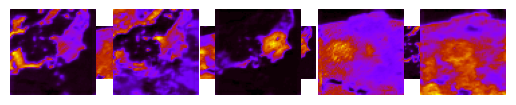

In [6]:
%%time
num_epochs = 20

for epoch in range(1, num_epochs+1):
    
    train_loss = 0                                                 
    model.train()
    i = 0
    for input, target in train_loader:
        output = model(input)
        if(i%10==0):
            print(input.mean())
            print(output.mean())
        output = output.nan_to_num(nan=0.0)
        # print(input.shape)
        # print(target.shape)
        loss = criterion(output.flatten(), target.flatten())       
        loss.backward()                                            
        optim.step()                                               
        optim.zero_grad()                                           
        train_loss += loss.item()
        i+=1
    train_loss /= len(train_loader.dataset)                       

    val_loss = 0                                                 
    model.eval()                                                   
    with torch.no_grad():                                          
        for input, target in val_loader:                          
            output = model(input)
            output = output.nan_to_num(nan=0.0)
            loss = criterion(output.flatten(), target.flatten())
            #loss = loss.clamp(0, 1)
            val_loss += loss.item()
            custom_imshow(target)
            custom_imshow(output)
    val_loss /= len(val_loader.dataset)                            

    print("Epoch:{} Training Loss:{:.8f} Validation Loss:{:.8f}\n".format(
        epoch, train_loss, val_loss))
    torch.cuda.empty_cache()
    torch.save(model.state_dict(), f"model_25_06_26_4_MSE_avg_{NUM_LAYERS}l_{num_epochs}e.h5")

In [24]:
    val_loss = 0                                                 
    model.eval()                                                   
    with torch.no_grad():                                          
        for input, target in val_loader:                          
            output = model(input)
            output = output.nan_to_num(nan=0.0)
            loss = criterion(output.flatten(), target.flatten())
            #loss = loss.clamp(0, 1)
            val_loss += loss.item()
    val_loss /= len(val_loader.dataset)                            

    print("Epoch:{} Training Loss:{:.6f} Validation Loss:{:.6f}\n".format(
        epoch, train_loss, val_loss))

Epoch:20 Training Loss:0.004901 Validation Loss:0.006796



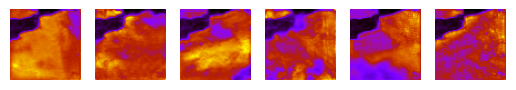

In [13]:
custom_imshow(target, save=True)
custom_imshow(output, save=True)
#custom_imshow(input[1])

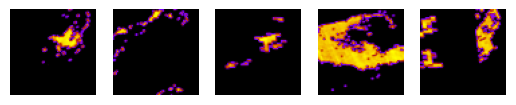

In [19]:
custom_imshow(target)

In [23]:
#torch.save(model.state_dict(), "model_25_06_26_1a_MSE_avg_4l_10e.h5")

In [ ]:
#x = torch.randn(5,1,19,64,64, dtype=torch.float).to(device)
#out = model(x)
dot = make_dot(input, params=dict(model.named_parameters()), show_attrs=True, show_saved=True)
dot
#dot.render("conv_lstm", format="png")

In [21]:
# model_path = "model_25_06_26_1a_MSE_avg_3l_10e.h5"
# model_path = "model_25_06_26_2_MSE_avg_3l_20e.h5"
# model_path = "model_25_06_26_3_MSE_avg_2l_10e.h5"
model_path = "./model_25_06_26_4_MSE_avg_2l_20e.h5"

model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

<All keys matched successfully>

In [6]:
# Load Data as Numpy Array
# sequences, seq_len, channels, height, width
test_data_CH4 = np.load("./data/input_convlstm/CH4_stacked_Paris_2022.npy").transpose(0,2,1,3,4)
# Shuffle Data
test_data_CH4 = np.float32(np.nan_to_num(test_data_CH4, nan=0.0))
print(test_data_CH4.mean())
np.random.shuffle(test_data_CH4)
print(test_data_CH4.shape)

test_targets_CH4 = torch.from_numpy(np.nan_to_num(test_data_CH4[:, :, 19, :, :], nan=0.0)).to(device)
test_data_CH4 = torch.from_numpy(np.nan_to_num(test_data_CH4[:, :, :19, :, :], nan=0.0)).to(device)
print(test_data_CH4.nbytes / 1024 / 1024)

test_dataset = TensorDataset(test_data_CH4, test_targets_CH4)#.to(device)

test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

0.17202906
(174, 1, 20, 64, 64)
51.65625


In [22]:
test_loss = 0                                                 
model.eval()
i = 0
with torch.no_grad():                                          
    for input, target in test_loader:                          
        output = model(input)
        output = output.nan_to_num(nan=0.0)
        loss = criterion(output.flatten(), target.flatten())
        #loss = loss.clamp(0, 1)
        test_loss += loss.item()
        i+=1
        print(f"{i}: {output[0].mean()} / {target[0].mean()}")
        break
test_loss /= len(val_loader.dataset)                            

#print("Epoch:{} Training Loss:{:.6f} Validation Loss:{:.6f}\n".format(epoch, train_loss, val_loss))
print("Test Loss:{:.6f}\n".format(test_loss))

1: 0.13434496521949768 / 0.09287919104099274
Test Loss:0.000315



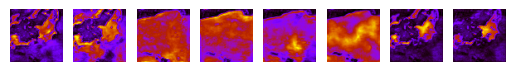

In [121]:
custom_imshow(target, save=False)
custom_imshow(output, save=False)

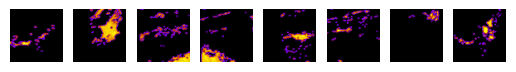

In [122]:
custom_imshow(target)

In [10]:
kernels = model.conv.weight.detach().clone()

C:\Users\Kajetan\AppData\Local\Temp\ipykernel_44604\2231086949.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(21, figsize=(8,0.8))


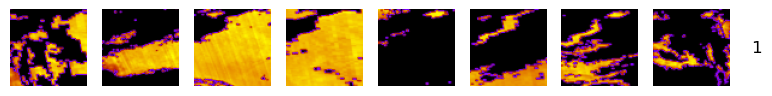

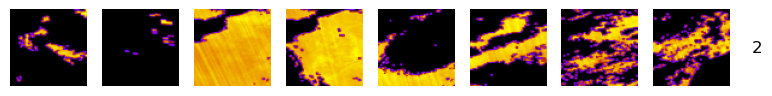

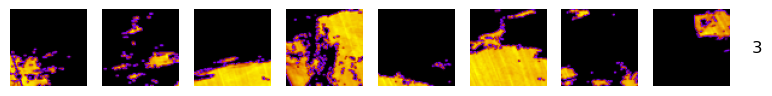

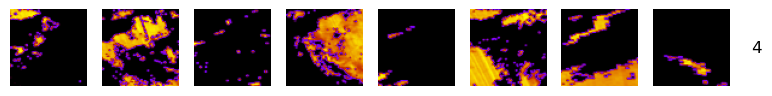

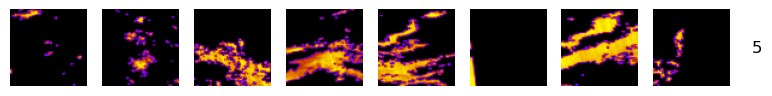

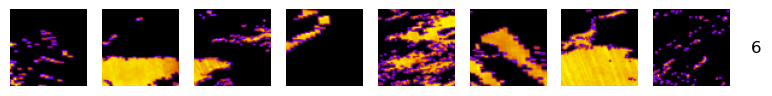

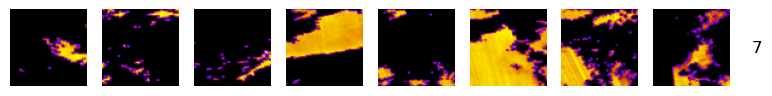

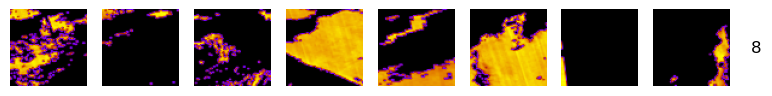

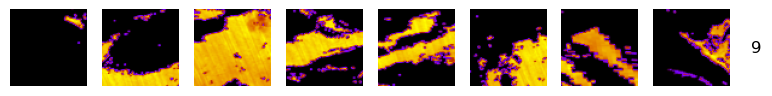

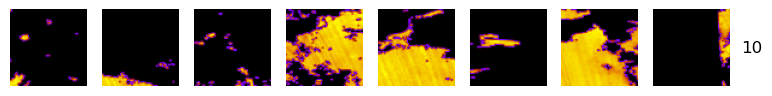

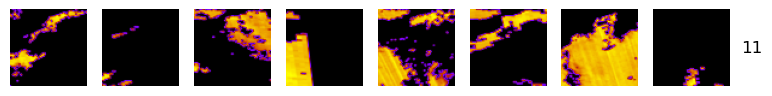

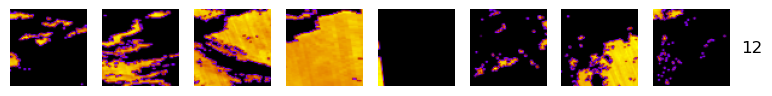

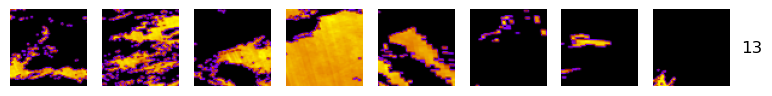

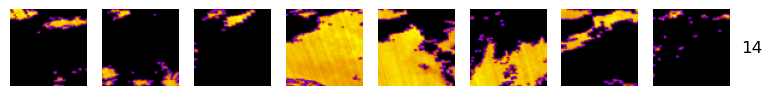

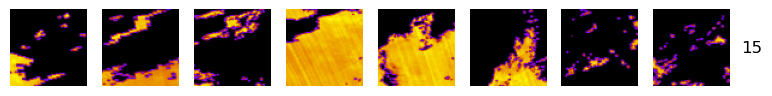

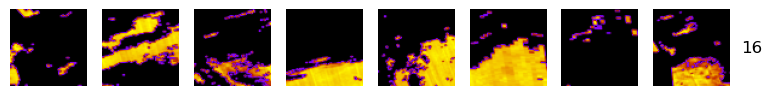

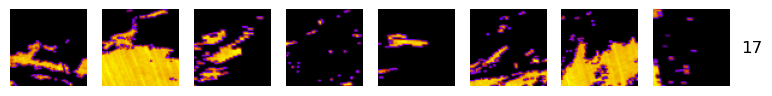

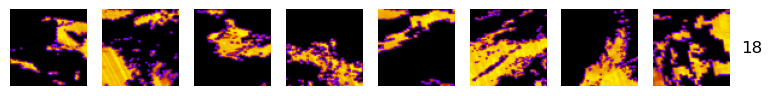

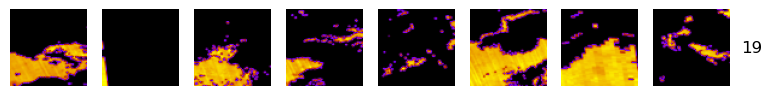

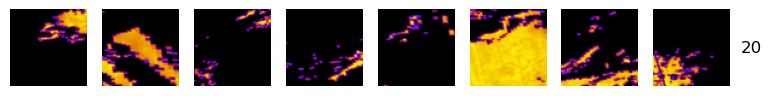

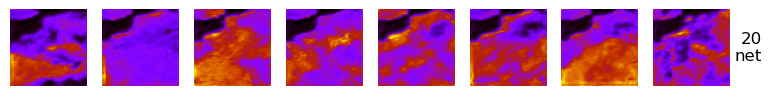

In [23]:
import os
net = 4
basepath = f"./data/export/final chapter/net {net} combined (FR)/"
os.makedirs(basepath, exist_ok=True)
for i in range(0,19):
    fig = plt.figure(i, figsize=(8,0.8))
    plt.suptitle(f"{i+1}", ha='right', va='center', x=0.99, y=0.5)
    fig.subplots_adjust(left=0.05, right=0.95, top=0.99, bottom=0.01)
    filepath = basepath+f"net{net}_{str(i+1).zfill(2)}.png"
    custom_imshow(input[:,:,i,:,:], save=True, filepath=filepath)
    # custom_imshow(input, save=True, filepath=filepath)
    
fig = plt.figure(20, figsize=(8,0.8))
plt.suptitle(f"{i+2}", ha='right', va='center', x=0.99, y=0.5)
fig.subplots_adjust(left=0.05, right=0.95, top=0.99, bottom=0.01)
filepath = basepath+f"net{net}_20.png"
custom_imshow(target, save=True, filepath=filepath)

fig = plt.figure(21, figsize=(8,0.8))
plt.suptitle(f"{i+2}\nnet", ha='right', va='center', x=0.99, y=0.5)
fig.subplots_adjust(left=0.05, right=0.95, top=0.99, bottom=0.01)
filepath = basepath+f"net{net}_20a.png"
custom_imshow(output, save=True, filepath=filepath)


output: 1677.7679443359375
target: 1794.2919921875


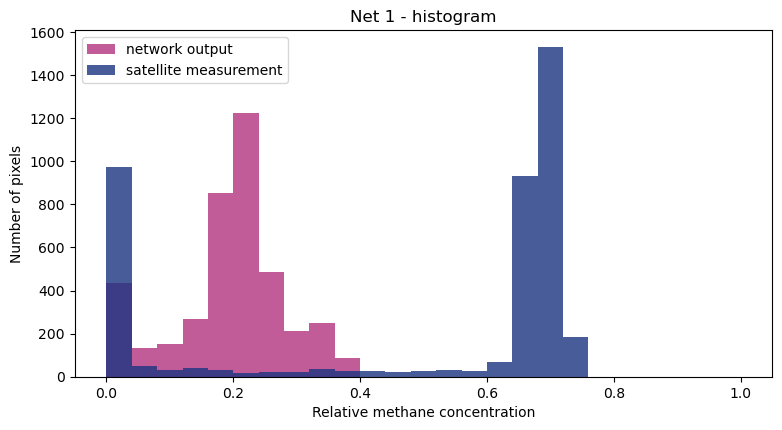

In [13]:
x = 2
plt.figure(figsize=(9, 4.5))
# plt.stairs(*np.histogram(input[x,:,18,:,:], range=(0, 1), bins=25), fill=True, label='historical');
plt.stairs(*np.histogram(output[x], range=(0, 1), bins=25), fill=True, label='network output', color=(0.7, 0.2, 0.5, 0.8));
plt.stairs(*np.histogram(target[x], range=(0, 1), bins=25), fill=True, label='satellite measurement', color=(0.1, 0.2, 0.5, 0.8));
print(f"output: {output[x].mean()*400+1600}")
print(f"target: {target[x].mean()*400+1600}")
plt.title(f"Net {net} - histogram")
plt.xlabel("Relative methane concentration")
plt.ylabel("Number of pixels")
plt.legend()
filepath = f"./data/export/final chapter/histogram_net{net}_FR.png"
plt.savefig(filepath)

In [13]:
kernels.size()
kernels

tensor([[[[ 0.0172, -0.0167, -0.0268],
          [ 0.0221,  0.0224, -0.0148],
          [ 0.0381,  0.0162, -0.0202]],

         [[-0.0123, -0.0347,  0.0107],
          [-0.0084,  0.0007, -0.0128],
          [ 0.0096,  0.0340, -0.0019]],

         [[ 0.0149, -0.0191,  0.0320],
          [-0.0120,  0.0244,  0.0281],
          [ 0.0056, -0.0222,  0.0103]],

         [[ 0.0082, -0.0162,  0.0423],
          [-0.0178,  0.0138, -0.0335],
          [-0.0254,  0.0092, -0.0306]],

         [[-0.0235,  0.0054, -0.0327],
          [ 0.0175,  0.0126,  0.0408],
          [-0.0022,  0.0081, -0.0256]],

         [[ 0.0141,  0.0305, -0.0119],
          [ 0.0265, -0.0094, -0.0170],
          [-0.0374, -0.0260,  0.0077]],

         [[-0.0208,  0.0073, -0.0008],
          [ 0.0197,  0.0275, -0.0300],
          [-0.0098, -0.0351, -0.0093]],

         [[-0.0109, -0.0134,  0.0267],
          [ 0.0103,  0.0130, -0.0324],
          [ 0.0011, -0.0098, -0.0036]],

         [[ 0.0199, -0.0156, -0.0028],
         

In [ ]:
import torchvision
kernels = kernels - kernels.min()
kernels = kernels / kernels.max()
filter_img = torchvision.utils.make_grid(kernels, nrow = 16)
# change ordering since matplotlib requires images to 
# be (H, W, C)
plt.imshow(filter_img.permute(1, 2, 0))

# You can directly save the image as well using
# img = save_image(kernels, 'encoder_conv1_filters.png' ,nrow = 16)